In [1]:
from platform import python_version
print(python_version())

3.11.14


### Cluster with Tahoe or sc-GTP

### Huggingface: tahoebio/Tahoe-x1-embeddings

https://github.com/tahoebio/tahoe-x1

Tahoe-x1: Scaling Perturbation-Trained Single-Cell Foundation Models to 3 Billion Parameters


#### Memory

That's not a general "64 GB isn't enough" — swap is fully exhausted at 2.0G, which means something asked for tens of GB in one allocation. Given where you are in the pipeline, the culprit is almost certainly load_tahoe_de, and the arithmetic says so:

The DE table is ~4.09e9 rows over ~75k conditions × ~54k genes. 

Filtering to pancreas doesn't help much — roughly 
- 6 lines × 379 drugs × ~4 doses × 54k genes ≈ 5e8 rows, 
- materialised in pandas with gene/drug/cell_line_id as object-dtype strings (~200 B/row) before pivot_table ever runs. 
- That's >100 GB. full_Z and consensus_cluster are megabytes by comparison.



In [2]:
import os, sys, yaml
from pathlib import Path
from dotenv import load_dotenv

import numpy as np
import pandas as pd
pd.set_option('display.width', 100)
pd.set_option('max_colwidth', 80)
pd.set_option("display.precision", 3)

import seaborn as sns
sns.set_context("notebook", font_scale=1.4)

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
%matplotlib inline

ROOT0 = Path("/home/flavio/uv/perturb_agent/")
ROOT_SRC = ROOT0 / "src"

sys.path.insert(0, ROOT_SRC)


if str(ROOT_SRC) not in sys.path:
    sys.path.append(str(ROOT_SRC))

print("ROOT0:", ROOT0)
print("ROOT_SRC added:", ROOT_SRC)

from libs.Basic import create_dir
from libs.MTD_lib import MTD
from libs.cBioPortal_lib import cBioPortal
from libs.calc_degs_lib import CALC_DEGS
# from libs.dashcyto_lib import DASH_CYTO
from libs.config_lib import Config
from libs.prism_lib import PRISM
from libs.prism_program_lib import *


from IPython.display import display, HTML
# display(HTML("<style>.container { width:100% !important; }</style>"))
display(HTML("<style>:root { --jp-notebook-max-width: 100% !important; }</style>"))

with open('../params.yml', 'r') as file:
    dic_yml = yaml.safe_load(file)

# print(dic_yml)

ROOT0: /home/flavio/uv/perturb_agent
ROOT_SRC added: /home/flavio/uv/perturb_agent/src


/home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages/Bio/__init__.py:138: BiopythonWarning: You may be importing Biopython from inside the source tree. This is bad practice and might lead to downstream issues. In particular, you might encounter ImportErrors due to missing compiled C extensions. We recommend that you try running your code from outside the source tree. If you are outside the source tree then you have a pyproject.toml file in an unexpected directory: /home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages
  warnings.warn(
/home/flavio/uv/perturb_agent/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
email = os.getenv('email')

i_project=0

project_list = dic_yml['project_list']
n = len(project_list)
project = project_list[i_project]

s_project_list = dic_yml['s_project_list']
s_project = s_project_list[i_project]
assert n==len(project_list), f"Error project_list: there are {n} projects"

PROG_ID = 'TCGA'
PSI_ID = 'BRCA'
PSI_ID = 'ACC'
PSI_ID = 'CESC'
PSI_ID = 'PAAD'

ROOT0_DATA = ROOT0 / "data"
root_colab = ROOT0_DATA / 'colab'
root_project = ROOT0_DATA / PROG_ID

disease = PSI_ID

root_project = create_dir(ROOT0_DATA, s_project)
root_disease = create_dir(root_project, PSI_ID)

CONTEXT_DISESE = 'xxxx'
context_disease = CONTEXT_DISESE

gene_protein = dic_yml['gene_protein']
s_omics = dic_yml['s_omics']

has_age = dic_yml['has_age']
has_gender = dic_yml['has_gender']

exp_normalization = dic_yml['exp_normalization']
normalization = 'quantile_norm' if exp_normalization == True else 'not_normalized'

LFC_cut_inf = dic_yml['LFC_cut_inf']
s_pathw_enrichm_method = dic_yml['s_pathw_enrichm_method']
ptw_min_num_of_degs_cut = dic_yml['ptw_min_num_of_degs_cut']

tolerance_pPMI = dic_yml['tolerance_pPMI']
type_sat_ptw_index = dic_yml['type_sat_ptw_index']
saturation_lfc_param = dic_yml['saturation_lfc_param']

pval_pathway_cutoff = dic_yml['pval_pathway_cutoff']
fdr_pathway_cutoff = dic_yml['fdr_pathway_cutoff']
num_of_genes_cutoff = dic_yml['num_of_genes_cutoff']
enr_db_list = dic_yml['enr_db_list']


case_list = dic_yml['case_list']
dic_case_list = dic_yml['dic_case_list']

std_filename      = dic_yml['std_filename']
std_filename_list = dic_yml['std_filename_list']

min_lfc_modulation = dic_yml['min_lfc_modulation']
num_of_genes_list  = dic_yml['num_of_genes_list']
pPMI_normalized  = dic_yml['pPMI_normalized']

#--- max len for formatting purposes
s_len_case  = dic_yml['s_len_case']

n_sentences = dic_yml['n_sentences']
run_list = dic_yml['run_list']
chosen_model_list = dic_yml['chosen_model_list']
i_dfp_list = dic_yml['i_dfp_list']
chosen_model_sampling = dic_yml['chosen_model_sampling']

fdr_ptw_cutoff_list = np.arange(0.05, 0.80, 0.05)
lfc_list = np.round(np.arange(1.0, -0.01, -.025), 3)
fdr_list = np.arange(0.05, 0.76, .01)

cfg = Config(root0=ROOT0, root_disease=root_disease, disease=disease, case_list=case_list)
case = case_list[0]

n_genes_annot_ptw, n_degs, n_degs_in_ptw, n_degs_not_in_ptw, degs_in_all_ratio = -1,-1,-1,-1,-1

LFC_cut, lfc_FDR_cut, n_degs, n_degs_up, n_degs_dw = cfg.get_best_lfc_cutoff(case, 'not_normalized')

print(f"project '{project}', s_project '{s_project}'")
print(f"G/P LFC cutoffs: lfc={LFC_cut:.3f}; fdr={lfc_FDR_cut:.3f} - LFC_cut_inf={LFC_cut_inf:.3f}")
print(f"Pathway cutoffs: pval={pval_pathway_cutoff:.3f}; fdr={fdr_pathway_cutoff:.3f}; num of genes={num_of_genes_cutoff}")

Best parameter file for LFC does not exist /home/flavio/uv/perturb_agent/data/TCGA/PAAD/config/all_lfc_cutoffs_PAAD.tsv
project 'TCGA', s_project 'TCGA'
G/P LFC cutoffs: lfc=1.000; fdr=0.050 - LFC_cut_inf=0.400
Pathway cutoffs: pval=0.050; fdr=0.050; num of genes=3


In [4]:
mtd = MTD(disease=disease, gene_protein=gene_protein, s_omics=s_omics, project=project, s_project=s_project, 
          root0=ROOT0, root0_data=ROOT0_DATA, prog_id=PROG_ID, psi_id=PSI_ID,
          case_list=case_list, dic_case_list=dic_case_list, has_age=has_age, has_gender=has_gender, exp_normalization=exp_normalization,
          std_filename=std_filename, std_filename_list=std_filename_list,
          geneset_num=0, ptw_min_num_of_degs_cut=ptw_min_num_of_degs_cut,
          tolerance_pPMI=tolerance_pPMI, s_pathw_enrichm_method=s_pathw_enrichm_method,
          LFC_cut_inf=LFC_cut_inf, fdr_ptw_cutoff_list=fdr_ptw_cutoff_list,
          num_of_genes_list=num_of_genes_list, lfc_list=lfc_list, fdr_list=fdr_list, 
          min_lfc_modulation=min_lfc_modulation, type_sat_ptw_index=type_sat_ptw_index,
          saturation_lfc_param=saturation_lfc_param, enr_db_list=enr_db_list, pPMI_normalized=pPMI_normalized)

print(">>> Roots", mtd.root0, mtd.root_disease)
case = case_list[0]
print(">>>", mtd.disease, case)

mtd.cfg.set_default_best_lfc_cutoff(mtd.normalization, LFC_cut=1, lfc_FDR_cut=0.05)
ret, degs, degs_ensembl, dfdegs = mtd.open_case(case, prompt_verbose=True, verbose=False)
print("\nEcho Parameters:")
print(mtd.echo_parameters())

>>> Roots /home/flavio/uv/perturb_agent /home/flavio/uv/perturb_agent/data/TCGA/PAAD
>>> PAAD Tumor
>>> case Tumor
>>> psi_id or disease: PAAD
Error: No data available for the specified PAAD.
Error: could not find /home/flavio/uv/perturb_agent/data/TCGA/PAAD/lfc/PAAD_final_LFC_Tumor_x_CTRL_not_normalized.tsv
No dflfc table was calculated for this case Tumor

Echo Parameters:
	0/0 DEGs/ensembl.
		Up 0/0 DEGs/ensembl.
		Dw 0/0 DEGs/ensembl.

Found 0 (best=3) pathways for geneset num=0 'Reactome_Pathways_2024'
Pathway cutoffs p-value=0.050 fdr=0.050 min genes=0.05No enrichment analysis was calculated.


In [5]:
cbio = cBioPortal(root0=ROOT0, root0_data=ROOT0_DATA, memory_restriction=False)

### Get all programs

In [6]:
verbose = False

df_psi = cbio.open_primary_site(verbose=verbose)
df_psi

,prog_id,cbioportal_study_id,active,gdc_project_id,psi_id,disease_id,disease_cd,primary_site,disease_context
0,TCGA,paad_tcga_pan_can_atlas_2018,True,TCGA-PAAD,PAAD,pancreatic_adenocarcinoma,PAAD,Pancreas,"TCGA pancreatic adenocarcinoma, PanCancer Atlas"
1,CPTAC3,paad_cptac_2021,True,CPTAC-3,PAAD,pancreatic_ductal_adenocarcinoma,PAAD,Pancreas,"CPTAC publication cohort, Cell 2021; 140 pancreatic cancers"
2,TCGA,skcm_tcga_pan_can_atlas_2018,True,TCGA-SKCM,SKCM,cutaneous_melanoma,SKCM,Skin,"TCGA skin cutaneous melanoma, PanCancer Atlas"
3,TCGA,brca_tcga_pan_can_atlas_2018,True,TCGA-BRCA,BRCA,breast_invasive_carcinoma,BRCA,Breast,"TCGA breast invasive carcinoma, PanCancer Atlas"
4,CPTAC2,brca_cptac_2020,True,CPTAC-2,BRCA,breast_cancer,BRCA,Breast,"CPTAC breast cancer publication cohort, Cell 2020"


### Open primary cites from cbio

In [7]:
PROG_ID = 'TCGA'
psi_id = 'PAAD'
psi_id = 'SKCM'
psi_id = 'BRCA'

PROG_ID = 'CPTAC2'
psi_id = 'BRCA'

PROG_ID = 'CPTAC3'
psi_id = 'PAAD'

### Prism - development

In [8]:
import anndata as ad

prism = PRISM(root0=ROOT0, root0_data=ROOT0_DATA)

verbose=True

prism.set_program_and_primary_site(prog_id=PROG_ID, psi_id=psi_id, verbose=verbose)

prism.root_singc, prism.root_singc.exists()

Table opened ((7, 9)) at '/home/flavio/uv/perturb_agent/data/cbioportal_study_mapping.tsv'

-----------------------------
>> prog_id: CPTAC3
>> psi_id: PAAD
>> primary_site: Pancreas
>> disease_id: pancreatic_ductal_adenocarcinoma
>> disease_cd: PAAD

-----------------------------
>> cbioportal_study_id: paad_cptac_2021
>> gdc_project_id: CPTAC-3

-----------------------------
>> root disease: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD
>> root samples: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/samples
>> root lfc: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/lfc
>> root mutations: /home/flavio/uv/perturb_agent/data/CPTAC3/PAAD/mutations
-----------------------------



(PosixPath('/home/flavio/uv/perturb_agent/data/single_cell'), True)

### Running prism

In [9]:
verbose=True

res = prism.open_bayesprism(verbose=verbose)
print(len(res.genes))

Loaded /home/flavio/uv/perturb_agent/data/single_cell/deconv.h5ad (6.8 MB)
1604


In [10]:
res.states

['Fibroblast cell',
 'Stellate cell',
 'Macrophage cell',
 'Endothelial cell',
 'T cell',
 'B cell',
 'Ductal cell type 2',
 'Endocrine cell',
 'Ductal cell type 1',
 'Acinar cell']

In [11]:
res.theta_type.columns

Index(['Acinar cell', 'B cell', 'Ductal cell type 1', 'Endocrine cell', 'Endothelial cell',
       'Fibroblast cell', 'Macrophage cell', 'Stellate cell', 'T cell', 'malignant'],
      dtype='object')

### Ductal cell type 1

"Ductal cell type 1" is the normal-like ductal population and stays in the environment compartment — which is what you want. If both had been mapped to malignant, purity would inflate. Verify with res.tumor_purity.groupby(meta["condition"]).describe(): normals near zero, tumors somewhere in 0.2–0.6.


### Ductal cell type 2

One malignant state means no Ductal cell type 2 subdivision, so subtype_malignant scores Moffitt signatures on a single pooled malignant profile. That still works — it's per-sample expression, so samples can differ — but it won't give you distinct malignant states in θ. For that you'd subcluster Ductal cell type 2 in the AnnData and write finer cell_state labels before calling pseudobulk_reference.

In [12]:
res.cell_type_expression("Ductal cell type 1").shape

(1604, 153)

In [13]:
res.cell_type_expression("Ductal cell type 2").shape

(1604, 153)

### 2. theta is now fixed -> expand Z to every gene

In [14]:
verbose=False
force=False

imax_tumor=250
imax_normal=50

exclude_prog_list=['CCLE']
disease_cd = 'PAAD'

dfn_tumor, dfn_normal, df_gtex, df_summ = cbio.get_all_data_from_disease(disease_cd=disease_cd, 
                                                           imax_tumor=imax_tumor, imax_normal=imax_normal,
                                                           exclude_prog_list=exclude_prog_list,
                                                           force=force, verbose=verbose)

verbose=True
force=False

df_bulk, df_meta = prism.build_bulk_matrix(dfn_tumor, dfn_normal, cbio.df_metadata, 
                                        keep_biotypes=("protein_coding", "lncRNA", "miRNA"),
                                        force=force, verbose=verbose)

force=False
verbose=True
fname = "count-matrix.txt"
fname_ad = fname.replace('.txt', '.h5ad')

adata = prism.load_matrix(fname=fname, sep=' ', force=force, verbose=verbose)

filename_ad = prism.root_singc / fname_ad
compression = "gzip"
# adata.write_h5ad(filename_ad, compression=compression)
print(f"AData saved as {filename_ad},  ({filename_ad.stat().st_size/1e6:.0f} MB), compressed with {compression}")


verbose=True
fname_celltype = "all_celltype.txt"
adata = prism.attach_celltypes(adata=adata, fname_celltype=fname_celltype, verbose=verbose)

ref, s2t = prism.pseudobulk_reference(adata)

Error reading csv/tsv '/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/lfc/expression_gtex_controls_counts.tsv': No columns to parse from file
Table opened ((27169, 153)) at '/home/flavio/uv/perturb_agent/data/single_cell/bulk_matrix.tsv'
Table opened ((153, 4)) at '/home/flavio/uv/perturb_agent/data/single_cell/bulk_metadata.tsv'
57,530 cells x 24,005 genes | obs: []
AData saved as /home/flavio/uv/perturb_agent/data/single_cell/count-matrix.h5ad,  (338 MB), compressed with gzip
all_celltype.txt columns: ['cluster']
                             cluster
cell.name                           
T1_AAACCTGAGATGTCGG  Fibroblast cell
T1_AAACGGGGTCATGCAT    Stellate cell
T1_AAAGATGCATGTTGAC  Macrophage cell
using type_col='cluster'
barcode overlap: 57,530 / 57,530
cell_type
malignant             11315
Ductal cell type 1    10317
Endothelial cell       9117
Fibroblast cell        6742
Stellate cell          5907
Macrophage cell        5361
T cell                 3660
B cell                 24

In [15]:
Zfull, gfull = prism.full_Z(res, df_bulk, ref)

In [16]:
dic = {}

for cell_state in res.states:
    print(cell_state)
    Z = prism.state_expression(Zfull, gfull, res, cell_state)
    dic[cell_state] = Z

Fibroblast cell
Stellate cell
Macrophage cell
Endothelial cell
T cell
B cell
Ductal cell type 2
Endocrine cell
Ductal cell type 1
Acinar cell


In [17]:
i=0
key = list(dic.keys())[i]

print(key)
dic[key]

Fibroblast cell


,T-C3L-02890,T-C3L-03635,T-C3L-02701,T-C3L-04072,T-C3L-00589,T-C3L-03123,T-C3N-01383,T-C3L-01124,T-C3L-00625,T-C3N-03439,...,N-C3N-03069,N-C3N-02765,N-C3L-07037,N-C3N-02589,N-C3N-02996,N-C3L-02606,N-C3N-03173,N-C3N-02696,N-TCGA-H6-8124,N-TCGA-H6-A45N
A1BG,6.551e-01,4.418e-01,6.680e-01,2.693e-01,4.914e-01,4.378e-01,1.043e+00,8.103e-01,9.495e-01,7.379e-01,...,NaN,0.772,0.328,NaN,NaN,NaN,1.515e-01,NaN,2.648e-01,NaN
A1BG-AS1,3.150e+00,1.251e+00,1.249e+00,2.249e+00,1.408e+00,1.848e+00,3.725e+00,1.988e+00,2.017e+00,2.263e+00,...,NaN,6.944,9.022,NaN,NaN,NaN,7.544e+00,NaN,1.126e+00,NaN
A1CF,3.463e+00,1.384e+00,2.188e+00,1.346e-01,1.305e+00,8.334e-02,1.176e+00,2.169e+00,1.218e+00,3.142e+00,...,NaN,1.033,3.148,NaN,NaN,NaN,1.032e+01,NaN,1.701e+00,NaN
A2M,1.344e+03,1.258e+03,1.165e+03,8.277e+02,1.477e+03,8.272e+02,1.130e+03,1.373e+03,2.035e+03,2.286e+03,...,NaN,1083.582,1060.576,NaN,NaN,NaN,2.068e+03,NaN,2.003e+03,NaN
A2M-AS1,6.254e+00,7.056e+00,2.835e+00,2.690e+00,5.443e+00,7.466e+00,6.568e+00,7.522e+00,6.423e+00,1.268e+01,...,NaN,2.626,7.625,NaN,NaN,NaN,1.319e+01,NaN,2.975e+00,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZYG11A,8.548e-09,2.341e-08,6.967e-08,7.866e-09,2.045e-08,2.942e-08,6.440e-08,2.001e-08,1.809e-07,1.226e-08,...,NaN,0.021,0.000,NaN,NaN,NaN,7.822e-08,NaN,6.635e-09,NaN
ZYG11B,1.060e+02,1.070e+02,1.151e+02,8.354e+01,1.278e+02,9.075e+01,1.159e+02,1.173e+02,9.685e+01,1.466e+02,...,NaN,53.810,83.431,NaN,NaN,NaN,1.003e+02,NaN,5.187e+01,NaN
ZYX,7.451e+01,5.875e+01,7.764e+01,1.232e+02,4.028e+01,7.744e+01,5.810e+01,6.771e+01,7.150e+01,5.684e+01,...,NaN,87.890,61.471,NaN,NaN,NaN,3.394e+01,NaN,3.417e+02,NaN
ZZEF1,1.460e+02,1.129e+02,9.541e+01,1.231e+02,1.044e+02,1.199e+02,1.055e+02,1.418e+02,1.251e+02,1.251e+02,...,NaN,129.316,99.746,NaN,NaN,NaN,5.434e+02,NaN,8.607e+01,NaN


### Ductal 2 - malignant

In [18]:
Zmal = prism.state_expression(Zfull, gfull, res, "Ductal cell type 2")

In [19]:
for g in ["FAM83A-AS1", "HOXA10-AS", "HOXB-AS3", "MIR7-3HG"]:
    if g in gfull:
        print(g, prism.gene_compartment_share(Zfull, gfull, res, g).head(3).round(3).to_dict())

FAM83A-AS1 {'Fibroblast cell': nan, 'Stellate cell': nan, 'Macrophage cell': nan}
HOXA10-AS {'Fibroblast cell': nan, 'Stellate cell': nan, 'Macrophage cell': nan}
HOXB-AS3 {'Fibroblast cell': nan, 'Stellate cell': nan, 'Macrophage cell': nan}
MIR7-3HG {'Fibroblast cell': nan, 'Stellate cell': nan, 'Macrophage cell': nan}


In [20]:
prog1 = ["FAM83A-AS1", "HOXA10-AS", "HOXB-AS3", "HOXB-AS4", "MIR7-3HG"]

prog2 = ["GATA6", "KRT17", "NEAT1", "H19", "DLEU1", "DLEU2"]

### survived build_bulk_matrix?

> Almost certainly df_bulk is the culprit: build_bulk_matrix defaults to keep_biotypes=("protein_coding",), which removes every lncRNA. Rebuild with them included:

In [21]:
[g for g in prog1 if g in df_bulk.index]

['FAM83A-AS1', 'HOXA10-AS', 'HOXB-AS3', 'HOXB-AS4', 'MIR7-3HG']

### present in the scRNA reference?

In [22]:
  
[g for g in prog1 if g in ref.columns]

['FAM83A-AS1', 'HOXA10-AS', 'HOXB-AS3', 'MIR7-3HG']

### Data treatment

1. get raw dfc
2. filter low-expression genes
3. normalize for library size
4. variance-stabilizing transformation
5. select most variable genes
6. cluster samples into k = 3..8 groups
7. evaluate clusters
8. find gene signatures for each cluster

A low-expression gene can be biologically important and even differentially expressed, especially if it is a transcription factor, cytokine, receptor, lncRNA, or rare-cell marker.

But for unsupervised tumor clustering, we usually do not want thousands of genes with mostly zero/very low counts because they add noise and unstable distances.

In [23]:
set(ref.index.to_list())

{'Acinar cell',
 'B cell',
 'Ductal cell type 1',
 'Ductal cell type 2',
 'Endocrine cell',
 'Endothelial cell',
 'Fibroblast cell',
 'Macrophage cell',
 'Stellate cell',
 'T cell'}

In [24]:
set(s2t.index.to_list())

{'Acinar cell',
 'B cell',
 'Ductal cell type 1',
 'Ductal cell type 2',
 'Endocrine cell',
 'Endothelial cell',
 'Fibroblast cell',
 'Macrophage cell',
 'Stellate cell',
 'T cell'}

In [25]:
adata.obs

,cluster,cell_type,cell_state
cell,,,
T1_AAACCTGAGATGTCGG,Fibroblast cell,Fibroblast cell,Fibroblast cell
T1_AAACGGGGTCATGCAT,Stellate cell,Stellate cell,Stellate cell
T1_AAAGATGCATGTTGAC,Macrophage cell,Macrophage cell,Macrophage cell
T1_AAAGATGGTCGAGTTT,Macrophage cell,Macrophage cell,Macrophage cell
T1_AAAGATGGTCTCTCTG,Endothelial cell,Endothelial cell,Endothelial cell
...,...,...,...
N11_TTTGCGCGTGCGCTTG,Endothelial cell,Endothelial cell,Endothelial cell
N11_TTTGGTTCATTGAGCT,Acinar cell,Acinar cell,Acinar cell
N11_TTTGGTTGTCCGACGT,Ductal cell type 1,Ductal cell type 1,Ductal cell type 1


In [26]:
import re, numpy as np, pandas as pd

adata.obs["sample"] = adata.obs_names.to_series().str.extract(r"^([TN]\d+)_")[0].values
adata.obs["tissue"] = np.where(adata.obs["sample"].str.startswith("T"), "tumor", "normal")

print(adata.obs.groupby("tissue")["sample"].nunique())      # expect tumor 24, normal 11
print(pd.crosstab(adata.obs["cell_state"], adata.obs["tissue"]))

tissue
normal    11
tumor     24
Name: sample, dtype: int64
tissue              normal  tumor
cell_state                       
Acinar cell           1423    512
B cell                  31   2416
Ductal cell type 1    7671   2646
Ductal cell type 2       0  11315
Endocrine cell         270    459
Endothelial cell      3983   5134
Fibroblast cell        940   5802
Macrophage cell        559   4802
Stellate cell          623   5284
T cell                  44   3616


### Count Malignant Cells - accordingo to transcriptomics

In [27]:
d2   = adata.obs["cell_state"].eq("Ductal cell type 2")
print(len(d2))
d2[:5]

57530


cell
T1_AAACCTGAGATGTCGG    False
T1_AAACGGGGTCATGCAT    False
T1_AAAGATGCATGTTGAC    False
T1_AAAGATGGTCGAGTTT    False
T1_AAAGATGGTCTCTCTG    False
Name: cell_state, dtype: bool

In [28]:
is_t = adata.obs["tissue"].eq("tumor")
print(np.sum(is_t))

41986


In [29]:
adata.obs["cell_state"] = np.where(d2 &  is_t, "Malignant ductal",
                          np.where(d2 & ~is_t, "Ductal cell type 2 normal",
                                   adata.obs["cell_state"]))
adata.obs

,cluster,cell_type,cell_state,sample,tissue
cell,,,,,
T1_AAACCTGAGATGTCGG,Fibroblast cell,Fibroblast cell,Fibroblast cell,T1,tumor
T1_AAACGGGGTCATGCAT,Stellate cell,Stellate cell,Stellate cell,T1,tumor
T1_AAAGATGCATGTTGAC,Macrophage cell,Macrophage cell,Macrophage cell,T1,tumor
T1_AAAGATGGTCGAGTTT,Macrophage cell,Macrophage cell,Macrophage cell,T1,tumor
T1_AAAGATGGTCTCTCTG,Endothelial cell,Endothelial cell,Endothelial cell,T1,tumor
...,...,...,...,...,...
N11_TTTGCGCGTGCGCTTG,Endothelial cell,Endothelial cell,Endothelial cell,N11,normal
N11_TTTGGTTCATTGAGCT,Acinar cell,Acinar cell,Acinar cell,N11,normal
N11_TTTGGTTGTCCGACGT,Ductal cell type 1,Ductal cell type 1,Ductal cell type 1,N11,normal


In [30]:
from collections import Counter

Counter(adata.obs["cell_state"] )

Counter({'Malignant ductal': 11315,
         'Ductal cell type 1': 10317,
         'Endothelial cell': 9117,
         'Fibroblast cell': 6742,
         'Stellate cell': 5907,
         'Macrophage cell': 5361,
         'T cell': 3660,
         'B cell': 2447,
         'Acinar cell': 1935,
         'Endocrine cell': 729})

In [31]:
adata.obs["cell_type"]  = np.where(adata.obs["cell_state"].eq("Malignant ductal"),
                                   "malignant", adata.obs["cell_type"])

Counter(adata.obs["cell_type"] )

Counter({'malignant': 11315,
         'Ductal cell type 1': 10317,
         'Endothelial cell': 9117,
         'Fibroblast cell': 6742,
         'Stellate cell': 5907,
         'Macrophage cell': 5361,
         'T cell': 3660,
         'B cell': 2447,
         'Acinar cell': 1935,
         'Endocrine cell': 729})

In [32]:
ref2, s2t = prism.pseudobulk_reference(adata, state_key="cell_state", type_key="cell_type")
s2t.to_dict()

{'Fibroblast cell': 'Fibroblast cell',
 'Stellate cell': 'Stellate cell',
 'Macrophage cell': 'Macrophage cell',
 'Endothelial cell': 'Endothelial cell',
 'T cell': 'T cell',
 'B cell': 'B cell',
 'Malignant ductal': 'malignant',
 'Endocrine cell': 'Endocrine cell',
 'Ductal cell type 1': 'Ductal cell type 1',
 'Acinar cell': 'Acinar cell'}

### LFC

calc_celltype_lfc() — each compartment vs the mean of the others, paired across samples by default. Paired is the right default here because every sample contributes every cell type, so pairing removes cohort/purity variance. This doubles as deconvolution QC: if the ductal compartment doesn't recover KRT19/TFF1/CEACAM6 and fibroblast doesn't recover COL1A1/POSTN, θ or the Peng reference is off and step 2 is meaningless.

### Critics

- Why not, for each cell type, tumor samples x normal samples
- Only Ductal 2 Tumor has no normal samples - to confirm


In [33]:
res.__dict__.keys()

dict_keys(['theta', 'theta_stage1', 'theta_type', 'tumor_purity', 'genes', 'Z', 'states'])

In [34]:
res.states

['Fibroblast cell',
 'Stellate cell',
 'Macrophage cell',
 'Endothelial cell',
 'T cell',
 'B cell',
 'Ductal cell type 2',
 'Endocrine cell',
 'Ductal cell type 1',
 'Acinar cell']

### Prism programs

In [35]:
Z_full, genes_full = prism.full_Z(res, df_bulk, ref)

### MalignantCluster

In [36]:
# del(MalignantCluster)

In [37]:
from libs.prism_malig_lib import MalignantCluster

In [38]:
type(res)

libs.prism_lib.DeconvResult

In [103]:
cbio.root_mprog_disease

PosixPath('/home/flavio/uv/perturb_agent/data/multi_progs/PAAD')

In [39]:
root_mprog_cluster = create_dir(cbio.root_mprog_disease, 'cluster')

cell_name = "Ductal cell type 2"
kmax = 8
no_decouple = True
is_tahoe = True
'''
mc = MalignantCluster(prism=prism, res=res, df_bulk=df_bulk, ref=ref, 
                      root_mprog_cluster=root_mprog_cluster, 
                      organ="Pancreas", cell_name=cell_name, cell_types=None)
'''

import importlib, libs.prism_malig_lib as pml
importlib.reload(pml)
print(pml.__version__)

0.19.0


In [40]:
mc = pml.MalignantCluster(prism, res, df_bulk, ref, root_mprog_cluster, organ="Pancreas")

X, diag = mc.prepare_malignant_matrix(keep_genes=mc.program1_panel)
print(X.shape)
X.head(3)

(125, 2000)


,A1CF,AACS,AADAC,AATK,ABAT,ABCA12,ABCA7,ABCB9,ABCC3,ABCC6,...,ZNF774,ZNF787,ZNF792,ZNF816,ZNF888,ZNRF1,ZNRF2,ZSCAN29,ZSWIM5,ZWINT
T-C3L-02890,6.339,6.394,5.173,5.321,5.810,3.304,6.691,5.138,7.894,3.771,...,3.659,5.141,4.990,4.945,6.294,4.822,5.624,5.873,4.213,5.154
T-C3L-03635,4.851,5.797,1.786,4.322,5.815,5.588,4.863,3.483,9.473,2.844,...,4.437,4.405,5.216,6.645,6.889,4.623,6.058,5.953,3.381,5.075
T-C3L-02701,5.459,6.252,2.637,5.297,5.755,4.061,6.086,3.164,8.562,3.482,...,4.564,4.759,4.606,5.259,6.386,4.851,5.279,5.854,4.099,5.349


In [41]:
diag.keys()

dict_keys(['samples_dropped', 'n_genes_expressed', 'n_genes_share_not_computable', 'n_genes_share_ok', 'forced_genes_status', 'n_genes_kept', 'covariates', 'n_hvg', 'pc_theta_pearson', 'theta_mal'])

### Inspecting vars

In [42]:
info = mc.inspect_de_schema(genes=X.columns)
print(info.keys())
info["columns"]

dict_keys(['shard_file', 'file_mb', 'total_rows_in_shard', 'columns', 'dtypes', 'head', 'distinct_gene_name', 'n_distinct_gene_name', 'distinct_baseMean', 'n_distinct_baseMean', 'distinct_log2FoldChange', 'n_distinct_log2FoldChange', 'distinct_lfcSE', 'n_distinct_lfcSE', 'distinct_stat', 'n_distinct_stat', 'distinct_pvalue', 'n_distinct_pvalue', 'distinct_padj', 'n_distinct_padj', 'distinct_plate', 'n_distinct_plate', 'distinct_n_cells_trt', 'n_distinct_n_cells_trt', 'distinct_n_cells_ctrl', 'n_distinct_n_cells_ctrl', 'distinct_Cell_ID_Cellosaur', 'n_distinct_Cell_ID_Cellosaur', 'distinct_Cell_ID_DepMap', 'n_distinct_Cell_ID_DepMap', 'distinct_drug', 'n_distinct_drug', 'distinct_concentration', 'n_distinct_concentration', 'distinct_concentration_unit', 'n_distinct_concentration_unit', 'distinct_Cell_Name_Vevo', 'n_distinct_Cell_Name_Vevo', 'cell_line_metadata_columns', 'MATCH cell_line_metadata.Cell_ID_Cellosaur -> DE.Cell_ID_Cellosaur', 'MATCH cell_line_metadata.cell_name -> DE.Cell_N

['gene_name',
 'baseMean',
 'log2FoldChange',
 'lfcSE',
 'stat',
 'pvalue',
 'padj',
 'plate',
 'n_cells_trt',
 'n_cells_ctrl',
 'Cell_ID_Cellosaur',
 'Cell_ID_DepMap',
 'drug',
 'concentration',
 'concentration_unit',
 'Cell_Name_Vevo']

In [43]:
info["matches"]

['MATCH cell_line_metadata.Cell_ID_Cellosaur -> DE.Cell_ID_Cellosaur',
 'MATCH cell_line_metadata.cell_name -> DE.Cell_Name_Vevo',
 'MATCH query genes -> DE.gene_name']

In [44]:
info["dtypes"]

{'gene_name': 'object',
 'baseMean': 'float32',
 'log2FoldChange': 'float32',
 'lfcSE': 'float32',
 'stat': 'float32',
 'pvalue': 'float32',
 'padj': 'float32',
 'plate': 'object',
 'n_cells_trt': 'int64',
 'n_cells_ctrl': 'int64',
 'Cell_ID_Cellosaur': 'object',
 'Cell_ID_DepMap': 'object',
 'drug': 'object',
 'concentration': 'float32',
 'concentration_unit': 'object',
 'Cell_Name_Vevo': 'object'}

In [45]:
info["resolved_columns"]

{'gene': 'gene_name',
 'stat': 'stat',
 'cell_line': 'Cell_ID_Cellosaur',
 'drug': 'drug'}

In [46]:
info["numeric_profile"]      # min / max / mean / frac_negative / n_unique


,min,max,mean,frac_negative,n_unique
baseMean,0.000,95136.398,36.460,0.000,69136
log2FoldChange,-4.858,7.180,0.081,0.232,68458
lfcSE,0.007,4.425,1.248,0.000,68449
stat,-46.548,73.326,0.019,0.232,68488
pvalue,0.000,1.000,0.470,0.000,68433
padj,0.000,1.000,0.586,0.000,23253
n_cells_trt,1378.000,2165.000,1745.045,0.000,4
n_cells_ctrl,4862.000,4862.000,4862.000,0.000,1
concentration,0.050,0.050,0.050,0.000,1


In [47]:
info["signed_candidates"]

['log2FoldChange', 'stat']

In [48]:
cov = mc.index_coverage()
cov["n_lines_seen"], cov["n_lines_in_metadata"]

(50, 102)

In [49]:
cov["block_probe_counts"]        # min probes per block

count    50.0
mean      3.4
std       0.5
min       3.0
25%       3.0
50%       3.0
75%       4.0
max       4.0
Name: count, dtype: float64

In [50]:
lista = cov["in_metadata_not_in_index"]
len(lista), lista[:5]

(52, ['CVCL_0025', 'CVCL_0031', 'CVCL_0039', 'CVCL_0060', 'CVCL_0078'])

In [51]:
cov["n_lines_seen"], cov["n_lines_in_metadata"]

(50, 102)

### Shards - A database shard, or simply a shard, is a horizontal partition of data within a database or search engine.

In [52]:
cvcl = mc.organ_cell_lines() 
mc.shard_index(stride=6)          # ~120 new footers, ~9 min (not 172)
shards = mc.find_shards_for(cvcl) # expect: located 11, missing 0

shard index: 172 cached, 0 to read (stride=6, 1026 shards total)
targets: 11 | located: 7 | missing: 4
shards to scan: 237/1026 (23%)  ~17 min at 4.3 s/shard
  NOT located: ['CVCL_0186', 'CVCL_1634', 'CVCL_1638', 'CVCL_1639']
  index resolves 50 distinct Cell_ID_Cellosaur values from 172 probes (gap~6).
  -> run index_coverage(): if these are absent from the DE table, no stride will find them and you should proceed without them.


In [53]:
dropped = ('CVCL_0186','CVCL_1634','CVCL_1638','CVCL_1639')
cvcl7  = [c for c in cvcl if c not in dropped]
shards = mc.find_shards_for(cvcl7)          # expect missing: 0

targets: 7 | located: 7 | missing: 0
shards to scan: 237/1026 (23%)  ~17 min at 4.3 s/shard


In [54]:
mc.shard_sizes(shards)

,shard,bytes
0,metadata/pseudobulk_differential_expression/train-00096-of-01026.parquet,92513713
1,metadata/pseudobulk_differential_expression/train-00097-of-01026.parquet,91964715
2,metadata/pseudobulk_differential_expression/train-00098-of-01026.parquet,92490710
3,metadata/pseudobulk_differential_expression/train-00099-of-01026.parquet,92183301
4,metadata/pseudobulk_differential_expression/train-00100-of-01026.parquet,88160979
...,...,...
232,metadata/pseudobulk_differential_expression/train-00920-of-01026.parquet,83238171
233,metadata/pseudobulk_differential_expression/train-00921-of-01026.parquet,80567798
234,metadata/pseudobulk_differential_expression/train-00922-of-01026.parquet,85303011
235,metadata/pseudobulk_differential_expression/train-00923-of-01026.parquet,89114559


In [55]:
mc.shard_sizes(shards)["bytes"].sum() / 1e9      # GB for the 237 shards

20.990016063

In [56]:
# to much: lets paralelize
# mc.download_shards(shards, dry_run=True)
mc.download_shards(shards, max_workers=8)

237 shards, 20.99 GB (median 90 MB/shard)


Fetching 237 files: 100%|██████████| 237/237 [00:00<00:00, 547.16it/s]


In [57]:
"""
df["condition"] = df["cell_line_id"].astype(str) + "|" + df["drug"].astype(str)
df_pivot = (df.pivot(index="gene", columns="condition", values="stat")
        .astype(dtype))
"""

df_pivot, cond = mc.load_tahoe_de(genes=X.columns.to_list(), organs=("Pancreas",),
                           mode="download", _shard_subset=shards, force=True)

Fetching 4 files: 100%|██████████| 4/4 [00:01<00:00,  2.01it/s]


In [58]:
print(df_pivot.shape)                                  # genes x conditions
df_pivot.head(8)

(1986, 2653)


condition,CVCL_0152|(R)-Verapamil (hydrochloride),CVCL_0152|(S)-Crizotinib,CVCL_0152|18β-Glycyrrhetinic acid,CVCL_0152|4EGI-1,CVCL_0152|5-Azacytidine,CVCL_0152|5-Fluorouracil,CVCL_0152|8-Hydroxyquinoline,CVCL_0152|9-ING-41,CVCL_0152|APTO-253,CVCL_0152|AT7519,...,CVCL_C466|Vortioxetine,CVCL_C466|XRK3F2,CVCL_C466|Zileuton,CVCL_C466|c-Kit-IN-1,CVCL_C466|crizotinib,CVCL_C466|olaparib,CVCL_C466|palbociclib,CVCL_C466|venetoclax,CVCL_C466|vincristine,CVCL_C466|γ-Oryzanol
gene,,,,,,,,,,,,,,,,,,,,,
A1CF,-0.466,0.383,-1.177,-1.062,-2.607,-1.135,0.060,-0.030,-0.668,0.689,...,0.149,-0.350,0.464,-0.076,-0.403,0.655,-2.550e-04,-0.048,0.723,1.146
AACS,1.064,-0.747,-0.181,0.564,0.458,0.089,0.664,-0.240,-0.316,0.969,...,-0.025,0.513,0.087,1.004,-0.070,-0.717,1.189e+00,0.121,0.867,-0.323
AADAC,-1.989,-0.931,-2.890,0.720,0.705,-0.181,-2.254,-3.302,0.457,-2.357,...,-0.268,-0.414,-0.749,0.410,-0.035,0.312,-8.589e-01,-0.785,0.170,0.220
AATK,-1.528,-0.021,0.608,-1.022,-0.063,1.126,-0.244,0.228,-0.989,0.116,...,-0.235,0.956,0.324,1.715,0.234,0.951,1.560e-01,0.641,-0.297,-0.003
ABAT,1.206,-0.828,-0.354,1.710,-0.696,-0.142,0.776,0.256,1.692,-0.156,...,0.591,1.612,-0.891,0.215,-1.004,0.633,4.112e-01,-0.837,-0.672,0.369
ABCA12,0.653,0.446,-0.005,1.170,0.720,0.768,-1.095,-0.373,0.827,0.706,...,0.199,-0.110,0.323,0.261,0.539,1.025,4.309e-01,0.839,1.100,0.599
ABCA7,0.078,-1.072,0.061,-1.091,-2.009,-0.626,-1.363,-1.342,-0.200,1.450,...,-0.727,-1.334,-0.821,0.770,0.311,0.344,-6.434e-01,0.086,0.027,0.087
ABCB9,1.334,-0.058,0.240,0.332,-0.341,-0.332,0.751,0.229,1.756,1.265,...,1.336,-0.934,-1.418,0.215,0.230,0.487,-8.274e-01,-0.293,-1.111,-0.331


In [59]:
cond.head(3)

,cell_line_id,drug,Cell_ID_Cellosaur,cell_name,Organ,moa-fine,moa-broad,targets,human-approved
condition,,,,,,,,,
CVCL_0152|(R)-Verapamil (hydrochloride),CVCL_0152,(R)-Verapamil (hydrochloride),CVCL_0152,AsPC-1,Pancreas,unclear,inhibitor/antagonist,ABCB1,no
CVCL_0152|(R)-Verapamil (hydrochloride),CVCL_0152,(R)-Verapamil (hydrochloride),CVCL_0152,AsPC-1,Pancreas,unclear,inhibitor/antagonist,ABCB1,no
CVCL_0152|(R)-Verapamil (hydrochloride),CVCL_0152,(R)-Verapamil (hydrochloride),CVCL_0152,AsPC-1,Pancreas,unclear,inhibitor/antagonist,ABCB1,no


In [60]:
cond["cell_line_id"].nunique(), cond["drug"].nunique()

(7, 379)

In [61]:
cond["cell_line_id"].value_counts()     # expect 7 lines

cell_line_id
CVCL_0152    2274
CVCL_0428    2274
CVCL_1635    2274
CVCL_0480    1895
CVCL_0334    1516
CVCL_1119    1137
CVCL_C466     379
Name: count, dtype: int64

In [62]:
cond["drug"].value_counts()


drug
(R)-Verapamil (hydrochloride)    31
Orlistat                         31
Palmatine (chloride)             31
Paclitaxel                       31
PH-797804                        31
                                 ..
Docetaxel (Trihydrate)           31
Docetaxel                        31
Diphenhydramine                  31
Dinaciclib                       31
γ-Oryzanol                       31
Name: count, Length: 379, dtype: int64

In [63]:
## 2D-values, stacked distribution
df_pivot.stack().describe()

count    5.233e+06
mean    -4.587e-02
std      1.697e+00
min     -5.551e+01
25%     -6.886e-01
50%     -5.311e-03
75%      6.471e-01
max      1.451e+02
dtype: float64

In [64]:
df_pivot<0

condition,CVCL_0152|(R)-Verapamil (hydrochloride),CVCL_0152|(S)-Crizotinib,CVCL_0152|18β-Glycyrrhetinic acid,CVCL_0152|4EGI-1,CVCL_0152|5-Azacytidine,CVCL_0152|5-Fluorouracil,CVCL_0152|8-Hydroxyquinoline,CVCL_0152|9-ING-41,CVCL_0152|APTO-253,CVCL_0152|AT7519,...,CVCL_C466|Vortioxetine,CVCL_C466|XRK3F2,CVCL_C466|Zileuton,CVCL_C466|c-Kit-IN-1,CVCL_C466|crizotinib,CVCL_C466|olaparib,CVCL_C466|palbociclib,CVCL_C466|venetoclax,CVCL_C466|vincristine,CVCL_C466|γ-Oryzanol
gene,,,,,,,,,,,,,,,,,,,,,
A1CF,True,False,True,True,True,True,False,True,True,False,...,False,True,False,True,True,False,True,True,False,False
AACS,False,True,True,False,False,False,False,True,True,False,...,True,False,False,False,True,True,False,False,False,True
AADAC,True,True,True,False,False,True,True,True,False,True,...,True,True,True,False,True,False,True,True,False,False
AATK,True,True,False,True,True,False,True,False,True,False,...,True,False,False,False,False,False,False,False,True,True
ABAT,False,True,True,False,True,True,False,False,False,True,...,False,False,True,False,True,False,False,True,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZNRF1,False,False,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,False,False,True,False
ZNRF2,False,False,False,False,True,False,False,False,False,False,...,False,False,False,True,True,False,False,True,True,False
ZSCAN29,True,True,True,False,False,False,False,False,False,False,...,False,False,True,False,True,False,False,False,False,True


In [65]:
float((df_pivot <= -1).mean().mean())

0.1759690619864874

In [66]:
(df_pivot >= 1).mean(axis=0)

condition
CVCL_0152|(R)-Verapamil (hydrochloride)    0.149
CVCL_0152|(S)-Crizotinib                   0.127
CVCL_0152|18β-Glycyrrhetinic acid          0.122
CVCL_0152|4EGI-1                           0.151
CVCL_0152|5-Azacytidine                    0.140
                                           ...  
CVCL_C466|olaparib                         0.247
CVCL_C466|palbociclib                      0.127
CVCL_C466|venetoclax                       0.163
CVCL_C466|vincristine                      0.175
CVCL_C466|γ-Oryzanol                       0.123
Length: 2653, dtype: float64

In [67]:
(df_pivot >= 1).mean(axis=1)

gene
A1CF       0.080
AACS       0.231
AADAC      0.079
AATK       0.140
ABAT       0.199
           ...  
ZNRF1      0.435
ZNRF2      0.230
ZSCAN29    0.435
ZSWIM5     0.163
ZWINT      0.454
Length: 1986, dtype: float64

### Cluster

#### All three checks pass

- 0.4989 negative confirms stat is a genuinely signed statistic 
- the WTCS sign convention is sound. 
- 1986 of 2000 HVGs found in Tahoe is 99.3% coverage, better than I expected for a Parse 3' assay.

#### Score it:

In [68]:
cc     = mc.consensus_cluster(X)
cc

{2: {'labels': T-C3L-02890       2
  T-C3L-03635       2
  T-C3L-02701       2
  T-C3L-04072       2
  T-C3L-00589       2
                   ..
  N-C3N-01719       2
  N-C3L-01689       2
  N-C3N-01899       2
  N-C3N-03173       2
  N-TCGA-H6-8124    2
  Name: k2, Length: 125, dtype: int32,
  'consensus':                 T-C3L-02890  T-C3L-03635  T-C3L-02701  T-C3L-04072  T-C3L-00589  T-C3L-03123  \
  T-C3L-02890             1.0          1.0          1.0          1.0          1.0          1.0   
  T-C3L-03635             1.0          1.0          1.0          1.0          1.0          1.0   
  T-C3L-02701             1.0          1.0          1.0          1.0          1.0          1.0   
  T-C3L-04072             1.0          1.0          1.0          1.0          1.0          1.0   
  T-C3L-00589             1.0          1.0          1.0          1.0          1.0          1.0   
  ...                     ...          ...          ...          ...          ...          ...   
  N-C3N

In [69]:
k      = mc.choose_k(cc)
k

2

In [70]:
labels = cc[k]["labels"]
sig    = mc.cluster_signatures(X, labels)
sig

{1: {'stat': A1CF       2.871e+00
  AACS       2.460e+00
  AADAC     -3.778e+00
  AATK       4.898e+00
  ABAT       1.068e+00
               ...    
  ZNRF1     -6.914e-01
  ZNRF2      9.066e-05
  ZSCAN29   -1.990e-01
  ZSWIM5     2.016e+00
  ZWINT     -4.755e+00
  Length: 2000, dtype: float64,
  'lfc': A1CF       1.576e+00
  AACS       9.077e-01
  AADAC     -2.701e+00
  AATK       1.933e+00
  ABAT       1.271e+00
               ...    
  ZNRF1     -2.911e-01
  ZNRF2      2.752e-05
  ZSCAN29   -5.527e-02
  ZSWIM5     8.299e-01
  ZWINT     -1.628e+00
  Length: 2000, dtype: float64,
  'up': ['PPFIA3',
   'SCAMP5',
   'KCNH2',
   'SEZ6L2',
   'CELSR3',
   'SRCIN1',
   'SMIM6',
   'SSTR1',
   'FOXP4',
   'DYRK1B',
   'GIPR',
   'FOXA2',
   'MED29',
   'RGL3',
   'ASPHD1',
   'SYNE4',
   'LRRC61',
   'FBXO41',
   'CDHR3',
   'AATK',
   'EEF1A2',
   'GOLGA7B',
   'EID2',
   'GPRIN1',
   'DUSP8',
   'TPPP',
   'SUSD4',
   'SLC25A29',
   'GABRB3',
   'DMKN',
   'ABLIM2',
   'UBE2M',
   'PAK6',

In [71]:
clu=2
sig[clu]['n'], len(sig[clu]['up']), len(sig[clu]['down'])

(119, 150, 150)

In [72]:
ups = set(sig[clu]['up'])
dwns = set(sig[clu]['down'])

ups.intersection(dwns), len(ups.union(dwns))

(set(), 300)

In [73]:
clu=1
sig[clu].keys()

dict_keys(['stat', 'lfc', 'up', 'down', 'n'])

In [74]:
sig[clu]['n'], len(sig[clu]['up']), len(sig[clu]['down'])

(6, 150, 150)

In [75]:
ups = set(sig[clu]['up'])
dwns = set(sig[clu]['down'])

ups.intersection(dwns), len(ups.union(dwns))

(set(), 300)

In [76]:
sig[clu]['up']

['PPFIA3',
 'SCAMP5',
 'KCNH2',
 'SEZ6L2',
 'CELSR3',
 'SRCIN1',
 'SMIM6',
 'SSTR1',
 'FOXP4',
 'DYRK1B',
 'GIPR',
 'FOXA2',
 'MED29',
 'RGL3',
 'ASPHD1',
 'SYNE4',
 'LRRC61',
 'FBXO41',
 'CDHR3',
 'AATK',
 'EEF1A2',
 'GOLGA7B',
 'EID2',
 'GPRIN1',
 'DUSP8',
 'TPPP',
 'SUSD4',
 'SLC25A29',
 'GABRB3',
 'DMKN',
 'ABLIM2',
 'UBE2M',
 'PAK6',
 'MANEAL',
 'BAIAP2',
 'CMTM8',
 'RAB17',
 'MYEF2',
 'PAF1',
 'RAP1GAP2',
 'SOCS7',
 'ABCA7',
 'RHPN1',
 'FAM174B',
 'TIGD5',
 'FIZ1',
 'UVSSA',
 'CBX4',
 'HNF1A-AS1',
 'SLC9A7',
 'C2orf16',
 'ZNF419',
 'MED25',
 'L1CAM',
 'HSPBP1',
 'ZNF579',
 'DDC',
 'SDHAF1',
 'CCDC24',
 'KIAA1549',
 'GSE1',
 'HNF1A',
 'KIAA0895',
 'C2CD4A',
 'MAP3K9',
 'PPP1R26',
 'MS4A8',
 'CYB561',
 'DNAJB2',
 'REPIN1',
 'KMT2B',
 'MIB2',
 'DHRS4-AS1',
 'SUPT5H',
 'PLXNB1',
 'PPP6R1',
 'A1CF',
 'PLEKHB1',
 'UBE2S',
 'AGFG2',
 'VWA7',
 'CEACAM19',
 'PLA2G6',
 'HCN3',
 'CACFD1',
 'KIF9',
 'NMNAT2',
 'CAMSAP3',
 'PRR12',
 'C2CD2L',
 'HID1',
 'BCAS4',
 'RSPH1',
 'EPHA10',
 'PCLO',
 

### signature_table()

In [77]:
len(labels), labels

(125,
 T-C3L-02890       2
 T-C3L-03635       2
 T-C3L-02701       2
 T-C3L-04072       2
 T-C3L-00589       2
                  ..
 N-C3N-01719       2
 N-C3L-01689       2
 N-C3N-01899       2
 N-C3N-03173       2
 N-TCGA-H6-8124    2
 Name: k2, Length: 125, dtype: int32)

In [78]:
dft = mc.signature_table(X, labels=labels,  min_abs_lfc=0.6, sort_by='fdr_nominal')
dft['abs_lfc'] = dft['lfc'].abs()

fdr_cutoff = 0.05
lfc_cutoff = 1

dft = dft[(dft.fdr_nominal < fdr_cutoff) & (dft.abs_lfc >= lfc_cutoff)]
dft = dft.sort_values('fdr_nominal', ascending=True)

dft.shape

(1856, 10)

<Axes: >

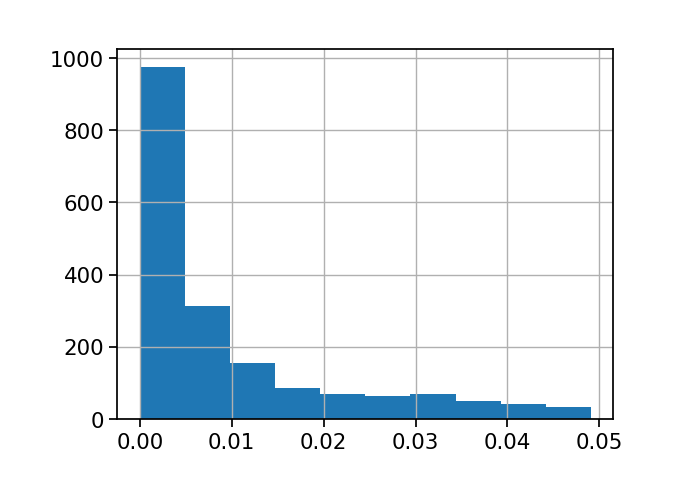

In [79]:
dft.fdr_nominal.hist()

In [80]:
dft.head(6)

,cluster,gene,lfc,stat,p_nominal,fdr_nominal,n_cluster,direction,rank,abs_lfc
1999,1,S100P,-6.864,-17.837,5.833e-34,5.833e-31,6,down,2000,6.864
3998,2,CYP2C18,3.868,11.596,3.093e-34,5.833e-31,119,up,1999,3.868
1998,1,CYP2C18,-3.868,-11.596,3.093e-34,5.833e-31,6,down,1999,3.868
3999,2,S100P,6.864,17.837,5.833e-34,5.833e-31,119,up,2000,6.864
3997,2,TRIM31,4.610,13.740,2.095e-32,1.397e-29,119,up,1998,4.610
1997,1,TRIM31,-4.610,-13.740,2.095e-32,1.397e-29,6,down,1998,4.610


In [81]:
genes_sel = sig[clu]['up']

df1 = dft[dft.gene.isin(genes_sel)]
print(f"Number of upregulated genes in cluster {clu}: {df1.shape[0]}")
df1

Number of upregulated genes in cluster 1: 206


,cluster,gene,lfc,stat,p_nominal,fdr_nominal,n_cluster,direction,rank,abs_lfc
3994,2,MED29,-1.346,-5.468,3.617e-19,1.206e-16,119,down,1995,1.346
1994,1,MED29,1.346,5.468,3.617e-19,1.206e-16,6,up,1995,1.346
1961,1,SCAMP5,2.968,8.766,1.069e-09,5.484e-08,6,up,1962,2.968
3961,2,SCAMP5,-2.968,-8.766,1.069e-09,5.484e-08,119,down,1962,2.968
3931,2,FOXA2,-1.938,-5.521,6.362e-08,1.844e-06,119,down,1932,1.938
...,...,...,...,...,...,...,...,...,...,...
925,1,OSBP2,1.161,2.129,2.309e-02,4.295e-02,6,up,926,1.161
2922,2,STK32A,-1.457,-2.274,2.335e-02,4.333e-02,119,down,923,1.457
922,1,STK32A,1.457,2.274,2.335e-02,4.333e-02,6,up,923,1.457
909,1,ATP9A,1.170,2.125,2.503e-02,4.588e-02,6,up,910,1.170


In [82]:
genes_clu = np.unique(df1.gene)
print(len(genes_clu))


103


In [83]:
genes_clu_in = [x for x in genes_clu if x in df_pivot.index]
df2 = df_pivot.loc[genes_clu_in]

print(df2.shape)
df2.T

(101, 2653)


gene,A1CF,AATK,ABCA7,ABLIM2,AGFG2,ASPHD1,ATP9A,BAIAP2,BCAS4,C2CD2L,...,SYNE4,TIGD5,TLCD1,TPPP,UBE2M,UBE2S,VWA7,WDR24,ZNF419,ZNF579
condition,,,,,,,,,,,,,,,,,,,,,
CVCL_0152|(R)-Verapamil (hydrochloride),-4.661e-01,-1.528,0.078,1.358,1.307,-1.160,1.626,0.637,0.606,0.161,...,-0.064,-0.375,0.083,-0.414,-0.168,-0.511,-0.025,-0.499,-0.814,-0.378
CVCL_0152|(S)-Crizotinib,3.828e-01,-0.021,-1.072,-0.790,0.490,1.980,-1.081,-1.006,-0.809,-0.600,...,0.703,-0.448,-0.165,0.794,0.301,-0.151,0.265,-1.240,0.159,-1.759
CVCL_0152|18β-Glycyrrhetinic acid,-1.177e+00,0.608,0.061,1.481,0.368,0.086,1.473,0.516,0.464,-0.369,...,-0.131,-0.628,-0.416,-0.966,0.372,-1.185,-0.312,-0.344,0.873,0.614
CVCL_0152|4EGI-1,-1.062e+00,-1.022,-1.091,4.849,0.162,2.355,1.201,-0.781,0.281,-0.299,...,0.750,0.152,0.056,0.419,-1.850,-0.605,0.139,-1.325,0.297,-0.112
CVCL_0152|5-Azacytidine,-2.607e+00,-0.063,-2.009,0.251,-0.434,2.251,-2.189,-0.290,0.392,0.754,...,0.601,-1.204,0.879,-0.674,-0.104,-1.011,-0.160,-0.410,0.147,0.080
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CVCL_C466|olaparib,6.555e-01,0.951,0.344,2.064,0.950,0.790,1.119,0.181,0.240,0.965,...,0.715,0.846,0.565,1.383,-1.566,0.030,0.305,0.955,0.871,0.357
CVCL_C466|palbociclib,-2.550e-04,0.156,-0.643,1.172,-0.893,0.314,1.029,0.617,-0.559,1.832,...,-0.431,-0.490,0.611,-0.007,-0.444,0.224,1.500,0.507,0.308,-0.414
CVCL_C466|venetoclax,-4.846e-02,0.641,0.086,0.871,-0.422,0.036,-0.478,-0.253,-0.028,-0.737,...,-0.308,0.384,0.073,0.192,0.406,-0.131,0.049,-0.703,0.465,-1.298


### WTCS (Weighted Connectivity Score) and NCS (Normalized Connectivity Score)

WTCS (Weighted Connectivity Score) and NCS (Normalized Connectivity Score) are core metrics used in the LINCS and Connectivity Map (CMap) pipelines to compare query gene signatures against reference expression profiles. 

- WTCS measures signature similarity from −1 to 1
- NCS normalizes these scores within specific cell lines and perturbagen types.

In [84]:
cond

,cell_line_id,drug,Cell_ID_Cellosaur,cell_name,Organ,moa-fine,moa-broad,targets,human-approved
condition,,,,,,,,,
CVCL_0152|(R)-Verapamil (hydrochloride),CVCL_0152,(R)-Verapamil (hydrochloride),CVCL_0152,AsPC-1,Pancreas,unclear,inhibitor/antagonist,ABCB1,no
CVCL_0152|(R)-Verapamil (hydrochloride),CVCL_0152,(R)-Verapamil (hydrochloride),CVCL_0152,AsPC-1,Pancreas,unclear,inhibitor/antagonist,ABCB1,no
CVCL_0152|(R)-Verapamil (hydrochloride),CVCL_0152,(R)-Verapamil (hydrochloride),CVCL_0152,AsPC-1,Pancreas,unclear,inhibitor/antagonist,ABCB1,no
CVCL_0152|(R)-Verapamil (hydrochloride),CVCL_0152,(R)-Verapamil (hydrochloride),CVCL_0152,AsPC-1,Pancreas,unclear,inhibitor/antagonist,ABCB1,no
CVCL_0152|(R)-Verapamil (hydrochloride),CVCL_0152,(R)-Verapamil (hydrochloride),CVCL_0152,AsPC-1,Pancreas,unclear,inhibitor/antagonist,ABCB1,no
...,...,...,...,...,...,...,...,...,...
CVCL_C466|olaparib,CVCL_C466,olaparib,CVCL_C466,hTERT-HPNE,Pancreas,DNA synthesis/repair inhibitor,unclear,"PARP1, PARP2",yes
CVCL_C466|palbociclib,CVCL_C466,palbociclib,CVCL_C466,hTERT-HPNE,Pancreas,CDK inhibitor,inhibitor/antagonist,"CDK4, CDK6",yes
CVCL_C466|venetoclax,CVCL_C466,venetoclax,CVCL_C466,hTERT-HPNE,Pancreas,unclear,inhibitor/antagonist,BCL2,yes


In [85]:
R1 = mc.score_clusters_vs_tahoe(sig, df_pivot, cond)
R1

,cluster,condition,wtcs,cell_line_id,drug,Cell_ID_Cellosaur,cell_name,Organ,moa-fine,moa-broad,targets,human-approved,ncs
0,1,CVCL_0480|Verteporfin,-0.395,CVCL_0480,Verteporfin,CVCL_0480,PANC-1,Pancreas,unclear,inhibitor/antagonist,YAP1,yes,-1.513
1,1,CVCL_0480|Verteporfin,-0.395,CVCL_0480,Verteporfin,CVCL_0480,PANC-1,Pancreas,unclear,inhibitor/antagonist,YAP1,yes,-1.513
2,1,CVCL_0480|Verteporfin,-0.395,CVCL_0480,Verteporfin,CVCL_0480,PANC-1,Pancreas,unclear,inhibitor/antagonist,YAP1,yes,-1.513
3,1,CVCL_0480|Verteporfin,-0.395,CVCL_0480,Verteporfin,CVCL_0480,PANC-1,Pancreas,unclear,inhibitor/antagonist,YAP1,yes,-1.513
4,1,CVCL_0480|Verteporfin,-0.395,CVCL_0480,Verteporfin,CVCL_0480,PANC-1,Pancreas,unclear,inhibitor/antagonist,YAP1,yes,-1.513
...,...,...,...,...,...,...,...,...,...,...,...,...,...
23493,2,CVCL_0480|Verteporfin,0.395,CVCL_0480,Verteporfin,CVCL_0480,PANC-1,Pancreas,unclear,inhibitor/antagonist,YAP1,yes,1.513
23494,2,CVCL_0480|Verteporfin,0.395,CVCL_0480,Verteporfin,CVCL_0480,PANC-1,Pancreas,unclear,inhibitor/antagonist,YAP1,yes,1.513
23495,2,CVCL_0480|Verteporfin,0.395,CVCL_0480,Verteporfin,CVCL_0480,PANC-1,Pancreas,unclear,inhibitor/antagonist,YAP1,yes,1.513
23496,2,CVCL_0480|Verteporfin,0.395,CVCL_0480,Verteporfin,CVCL_0480,PANC-1,Pancreas,unclear,inhibitor/antagonist,YAP1,yes,1.513


In [86]:
len(R1.targets.unique()), R1.targets.unique()[:20]

(190,
 array(['YAP1', 'AURKB', None, 'AR', nan, 'RET', 'CSF1R, KIT, FLT3',
        'ULK1, ULK2', 'RARA, RARB, RARG', 'FGFR1, FGFR2, FGFR3, FGFR4',
        'PTGS2', 'SSTR1, SSTR2, SSTR3, SSTR5', 'TOP2A', 'SMO', 'ABL1',
        'BTK', 'MYC, KLF4', 'EGFR, KDR', 'ARPC2', 'TYMS'], dtype=object))

In [87]:
target_list = R1.targets.unique()
len(target_list), len(genes_clu)

(190, 103)

In [88]:
[x for x in target_list if x in genes_clu]

['KCNH2']

In [89]:
R1a = R1[ (R1.cluster == clu) & (R1.targets.isin(genes_clu)) & (R1.wtcs.abs() > 0.1) ]
print(R1a.shape)
R1a

(9, 13)


,cluster,condition,wtcs,cell_line_id,drug,Cell_ID_Cellosaur,cell_name,Organ,moa-fine,moa-broad,targets,human-approved,ncs
505,1,CVCL_C466|Quinidine (15% dihydroquinidine),-0.261,CVCL_C466,Quinidine (15% dihydroquinidine),CVCL_C466,hTERT-HPNE,Pancreas,unclear,inhibitor/antagonist,KCNH2,yes,-1.129
1651,1,CVCL_1119|Quinidine (15% dihydroquinidine),-0.248,CVCL_1119,Quinidine (15% dihydroquinidine),CVCL_1119,CFPAC-1,Pancreas,unclear,inhibitor/antagonist,KCNH2,yes,-0.917
1652,1,CVCL_1119|Quinidine (15% dihydroquinidine),-0.248,CVCL_1119,Quinidine (15% dihydroquinidine),CVCL_1119,CFPAC-1,Pancreas,unclear,inhibitor/antagonist,KCNH2,yes,-0.917
1653,1,CVCL_1119|Quinidine (15% dihydroquinidine),-0.248,CVCL_1119,Quinidine (15% dihydroquinidine),CVCL_1119,CFPAC-1,Pancreas,unclear,inhibitor/antagonist,KCNH2,yes,-0.917
1934,1,CVCL_0480|Quinidine (15% dihydroquinidine),-0.226,CVCL_0480,Quinidine (15% dihydroquinidine),CVCL_0480,PANC-1,Pancreas,unclear,inhibitor/antagonist,KCNH2,yes,-0.866
1935,1,CVCL_0480|Quinidine (15% dihydroquinidine),-0.226,CVCL_0480,Quinidine (15% dihydroquinidine),CVCL_0480,PANC-1,Pancreas,unclear,inhibitor/antagonist,KCNH2,yes,-0.866
1936,1,CVCL_0480|Quinidine (15% dihydroquinidine),-0.226,CVCL_0480,Quinidine (15% dihydroquinidine),CVCL_0480,PANC-1,Pancreas,unclear,inhibitor/antagonist,KCNH2,yes,-0.866
1937,1,CVCL_0480|Quinidine (15% dihydroquinidine),-0.226,CVCL_0480,Quinidine (15% dihydroquinidine),CVCL_0480,PANC-1,Pancreas,unclear,inhibitor/antagonist,KCNH2,yes,-0.866
1938,1,CVCL_0480|Quinidine (15% dihydroquinidine),-0.226,CVCL_0480,Quinidine (15% dihydroquinidine),CVCL_0480,PANC-1,Pancreas,unclear,inhibitor/antagonist,KCNH2,yes,-0.866


In [90]:
R1a.targets.unique()

array(['KCNH2'], dtype=object)

In [91]:
R1.groupby("cluster").head(10)[["cluster","cell_name","drug","moa-fine","ncs"]]   # reversers

,cluster,cell_name,drug,moa-fine,ncs
0,1,PANC-1,Verteporfin,unclear,-1.513
1,1,PANC-1,Verteporfin,unclear,-1.513
2,1,PANC-1,Verteporfin,unclear,-1.513
3,1,PANC-1,Verteporfin,unclear,-1.513
4,1,PANC-1,Verteporfin,unclear,-1.513
5,1,MIA PaCa-2,TAK-901,unclear,-1.512
6,1,MIA PaCa-2,TAK-901,unclear,-1.512
7,1,MIA PaCa-2,TAK-901,unclear,-1.512
8,1,MIA PaCa-2,TAK-901,unclear,-1.512
9,1,MIA PaCa-2,TAK-901,unclear,-1.512


In [92]:
R1.groupby("cluster").tail(10)[["cluster","cell_name","drug","moa-fine","ncs"]] 

,cluster,cell_name,drug,moa-fine,ncs
11739,1,Hs 766T,Belinostat,HDAC inhibitor,1.605
11740,1,PANC-1,Trametinib,MEK inhibitor,1.612
11741,1,PANC-1,Trametinib,MEK inhibitor,1.612
11742,1,PANC-1,Trametinib,MEK inhibitor,1.612
11743,1,PANC-1,Trametinib,MEK inhibitor,1.612
11744,1,PANC-1,Trametinib,MEK inhibitor,1.612
11745,1,Hs 766T,Panobinostat,HDAC inhibitor,1.838
11746,1,Hs 766T,Panobinostat,HDAC inhibitor,1.838
11747,1,Hs 766T,Panobinostat,HDAC inhibitor,1.838
11748,1,Hs 766T,Panobinostat,HDAC inhibitor,1.838


In [93]:
out = mc.run(ks=range(2, 9), min_share=0.3)     # tune from diagnose_filters()
R   = mc.score_clusters_vs_tahoe(out["signatures"], df_pivot, cond)

In [94]:
R.groupby("cluster").head(10)[["cluster","cell_name","drug","moa-fine","ncs"]]   # reversers

,cluster,cell_name,drug,moa-fine,ncs
0,1,PANC-1,Verteporfin,unclear,-1.615
1,1,PANC-1,Verteporfin,unclear,-1.615
2,1,PANC-1,Verteporfin,unclear,-1.615
3,1,PANC-1,Verteporfin,unclear,-1.615
4,1,PANC-1,Verteporfin,unclear,-1.615
5,1,MIA PaCa-2,TAK-901,unclear,-1.576
6,1,MIA PaCa-2,TAK-901,unclear,-1.576
7,1,MIA PaCa-2,TAK-901,unclear,-1.576
8,1,MIA PaCa-2,TAK-901,unclear,-1.576
9,1,MIA PaCa-2,TAK-901,unclear,-1.576


In [95]:
R.groupby("cluster").tail(10)[["cluster","cell_name","drug","moa-fine","ncs"]] 

,cluster,cell_name,drug,moa-fine,ncs
11739,1,AsPC-1,Panobinostat,HDAC inhibitor,1.731
11740,1,AsPC-1,Panobinostat,HDAC inhibitor,1.731
11741,1,Hs 766T,Belinostat,HDAC inhibitor,1.743
11742,1,Hs 766T,Belinostat,HDAC inhibitor,1.743
11743,1,Hs 766T,Belinostat,HDAC inhibitor,1.743
11744,1,Hs 766T,Belinostat,HDAC inhibitor,1.743
11745,1,Hs 766T,Panobinostat,HDAC inhibitor,1.924
11746,1,Hs 766T,Panobinostat,HDAC inhibitor,1.924
11747,1,Hs 766T,Panobinostat,HDAC inhibitor,1.924
11748,1,Hs 766T,Panobinostat,HDAC inhibitor,1.924


In [96]:
# mc.root_mprog_tahoe = create_dir(mc.root_mprog_cluster / "tahoe")
mc.root_mprog_tahoe

PosixPath('/home/flavio/uv/perturb_agent/data/multi_progs/PAAD/cluster/tahoe')

In [97]:
d = mc.root_mprog_tahoe / "metadata" / "pseudobulk_differential_expression"
files = sorted(d.glob("*.parquet"))
len(files), sum(f.stat().st_size for f in files) / 1e9

(237, 20.990016063)

In [98]:
cl = pd.read_parquet(mc.root_mprog_tahoe / "metadata"/ "cell_line_metadata.parquet")
cl[cl.Organ=="Pancreas"][["Cell_ID_Cellosaur","cell_name"]]

,Cell_ID_Cellosaur,cell_name
388,CVCL_0428,MIA PaCa-2
389,CVCL_0428,MIA PaCa-2
390,CVCL_0428,MIA PaCa-2
391,CVCL_0428,MIA PaCa-2
392,CVCL_0428,MIA PaCa-2
393,CVCL_0428,MIA PaCa-2
445,CVCL_1119,CFPAC-1
446,CVCL_1119,CFPAC-1
447,CVCL_1119,CFPAC-1
448,CVCL_0152,AsPC-1


In [99]:
d = mc.diagnose_filters()

d["Z_looks_like_counts"], d["Z_median_of_medians"]


(True, 17.24835968017578)

In [100]:
d["by_min_counts"]

min_counts
0.0     16550
1.0     13266
5.0     10945
10.0     9666
50.0     4525
Name: n_genes, dtype: int64

In [101]:
d["by_min_share"]

min_share
0.0    16467
0.2    12999
0.3    10748
0.4     6538
0.5     3585
0.6     2376
0.7     1669
0.8     1066
Name: n_genes, dtype: int64

In [102]:
d["joint_grid"]

min_share,0.0,0.2,0.3,0.4,0.5,0.6,0.7,0.8
min_counts,,,,,,,,
0.0,16467,12999,10748,6538,3585,2376,1669,1066
1.0,13266,11505,9614,5661,2909,1838,1234,736
5.0,10945,9997,8457,4825,2326,1412,915,531
10.0,9666,9025,7743,4376,2040,1222,798,459
50.0,4525,4390,3983,2411,1115,660,434,262
